In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle

from models.models import HierarchicalPanelICA
import pymc as pm

from pathlib import Path


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from insilico_stimuli.stimuli import GaborSet, CenterSurround

import pytensor.tensor as pt

seed = 42


seed = 42
rng = np.random.default_rng(seed)

In [28]:
# posterior_samples_path = Path("/src/project/experiments")
# posterior_samples = []
# prior_samples = []
# for entry in posterior_samples_path.iterdir():
#     if entry.name.startswith("post_samples") and entry.suffix == ".pkl":
#         with open(entry, "rb") as f:
#             posterior_samples.append(pickle.load(f, encoding="latin1"))
#     elif entry.name.startswith("prior_samples") and entry.suffix == ".pkl":
#         with open(entry, "rb") as f:
#             prior_samples.append(pickle.load(f, encoding="latin1"))

In [29]:
with open("post_samples_0.pkl", "rb") as f:
    post_samples_ex = pickle.load(f)

with open("post_samples_1.pkl", "rb") as f:
    post_samples_in = pickle.load(f)

In [43]:
with open("prior_samples.pkl", "rb") as f:
    prior_samples = pickle.load(f)

In [73]:
with open("post_samples_center_and_blank_0.pkl", "rb") as f:
    post_samples_mei = pickle.load(f)

In [78]:
with open("post_samples_183_MEI.pkl", "rb") as f:
    post_samples_MEI_183 = pickle.load(f)

In [81]:
with open("inhibitory_183_samples.pkl", "rb") as file:
    post_samples_inhibitory_183 = pickle.load(file)

In [85]:
with open("excitatory_183_samples.pkl", "rb") as file:
    post_samples_excitatory_183 = pickle.load(file)

In [30]:
chains, draws_per_chain, G_dim = post_samples_ex["posterior"]["G"].data.shape

In [31]:
_, _, X_dim = post_samples_ex["posterior"]["X_mu"].shape

In [86]:
G_prior_samples = prior_samples["G"]
G_prior_samples_mean = G_prior_samples.mean(axis=0)

G_samples_ex = post_samples_ex["posterior"]["G"].data.reshape(
    chains * draws_per_chain, G_dim
)
G_samples_in = post_samples_in["posterior"]["G"].data.reshape(
    chains * draws_per_chain, G_dim
)
G_samples_mei = post_samples_mei["posterior"]["G"].data.reshape(
    chains * draws_per_chain, G_dim
)
G_samples_mei_183 = post_samples_MEI_183["posterior"]["G"].data.reshape(
    chains * draws_per_chain, G_dim
)
G_samples_inhibitory_183 = post_samples_inhibitory_183["posterior"]["G"].data.reshape(
    chains * draws_per_chain, G_dim
)

G_samples_mean_ex = G_samples_ex.mean(axis=0)
G_samples_mean_in = G_samples_in.mean(axis=0)
G_samples_mean_mei = G_samples_mei.mean(axis=0)

X_mu_prior_samples = prior_samples["X_mu"]
X_prior_samples = prior_samples["X"]
X_prior_samples_mean = X_prior_samples.mean(axis=0)

X_mu_samples_ex = post_samples_ex["posterior"]["X_mu"].data.reshape(
    chains * draws_per_chain, X_dim
)
X_mu_samples_in = post_samples_in["posterior"]["X_mu"].data.reshape(
    chains * draws_per_chain, X_dim
)
X_mu_samples_mei = post_samples_mei["posterior"]["X_mu"].data.reshape(
    chains * draws_per_chain, X_dim
)
X_mu_samples_mei_183 = post_samples_MEI_183["posterior"]["X_mu"].data.reshape(
    chains * draws_per_chain, X_dim
)

X_samples_ex = post_samples_ex["posterior"]["X"].data.reshape(
    chains * draws_per_chain, X_dim
)
X_samples_in = post_samples_in["posterior"]["X"].data.reshape(
    chains * draws_per_chain, X_dim
)
X_samples_mei = post_samples_mei["posterior"]["X"].data.reshape(
    chains * draws_per_chain, X_dim
)
X_samples_mei_183 = post_samples_MEI_183["posterior"]["X"].data.reshape(
    chains * draws_per_chain, X_dim
)
X_samples_inhibitory_183 = post_samples_inhibitory_183["posterior"]["X"].data.reshape(
    chains * draws_per_chain, X_dim
)
X_samples_excitatory_183 = post_samples_excitatory_183["posterior"]["X"].data.reshape(
    chains * draws_per_chain, X_dim
)

X_samples_mean_ex = X_samples_ex.mean(axis=0)
X_samples_mean_in = X_samples_in.mean(axis=0)
X_samples_mean_mei = X_samples_mei.mean(axis=0)
X_samples_mean_mei_183 = X_samples_mei_183.mean(axis=0)
X_samples_mean_inhibitory_183 = X_samples_inhibitory_183.mean(axis=0)
X_samples_mean_excitatory_183 = X_samples_excitatory_183.mean(axis=0)

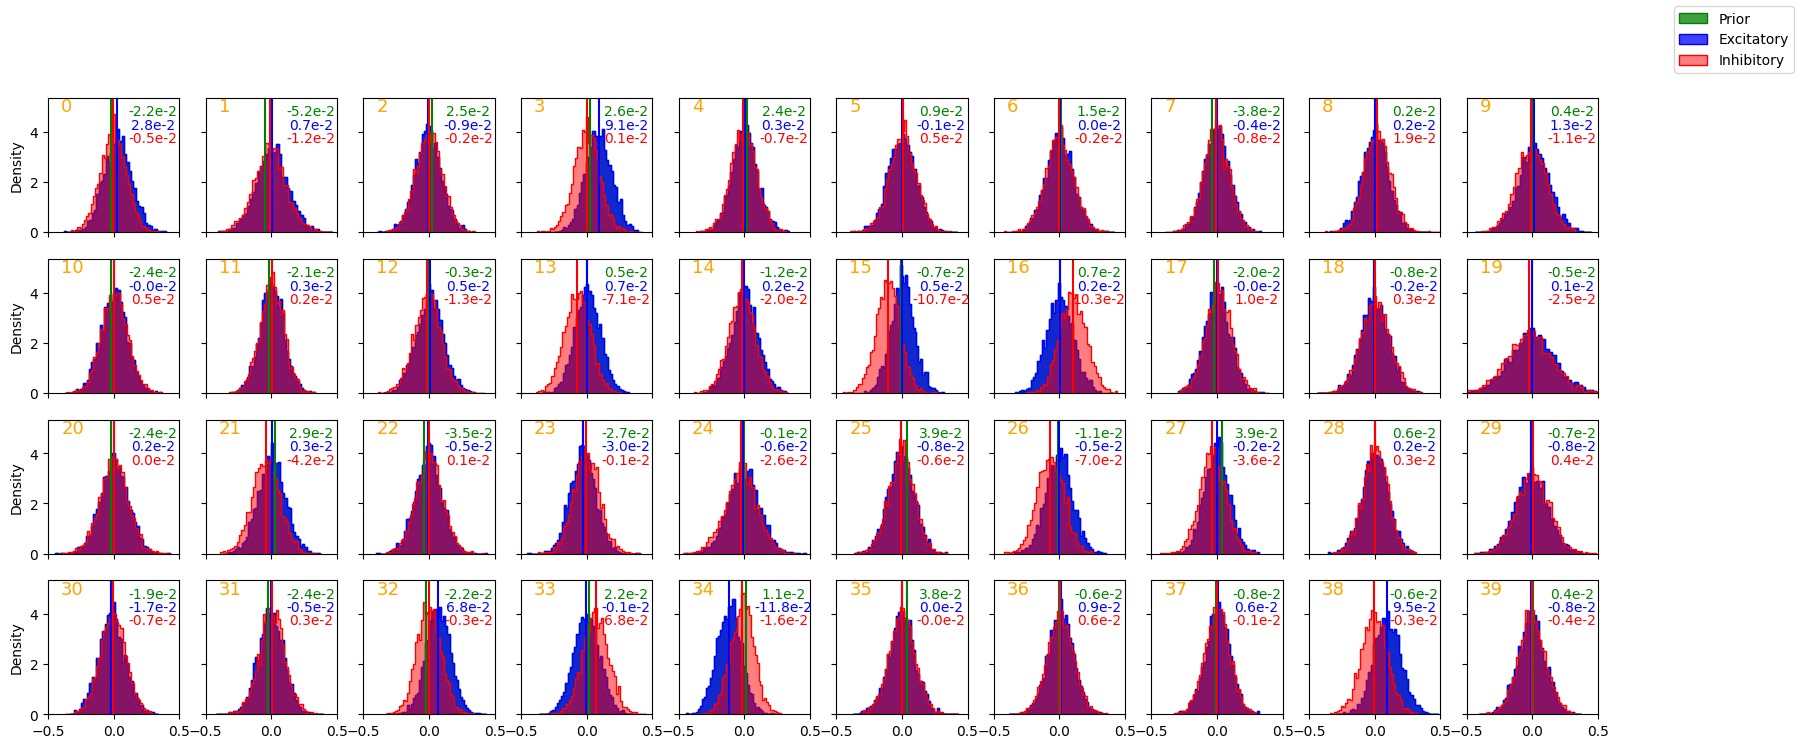

In [53]:
fig, axs = plt.subplots(
    nrows=4, ncols=10, figsize=(2 * 10, 2 * 4), sharex=True, sharey=True
)
for i, ax in enumerate(axs.flatten()):
    sns.histplot(
        G_samples_ex[:, i],
        ax=ax,
        stat="density",
        label="Prior",
        color="green",
        element="step",
    )
    sns.histplot(
        G_samples_ex[:, i],
        ax=ax,
        stat="density",
        label="Excitatory",
        color="blue",
        element="step",
    )
    sns.histplot(
        G_samples_in[:, i],
        ax=ax,
        stat="density",
        label="Inhibitory",
        color="red",
        element="step",
        alpha=0.5,
    )
    ax.axvline(G_prior_samples_mean[i], color="green", linestyle="-")
    ax.axvline(G_samples_mean_ex[i], color="blue", linestyle="-")
    ax.axvline(G_samples_mean_in[i], color="red", linestyle="-")
    ax.text(
        0.8,
        0.9,
        f"{G_samples_mean_ex[i]*100:.1f}e-2",
        size=10,
        ha="center",
        va="center",
        transform=ax.transAxes,
        color="green",
    )
    ax.text(
        0.8,
        0.8,
        f"{G_samples_mean_ex[i]*100:.1f}e-2",
        size=10,
        ha="center",
        va="center",
        transform=ax.transAxes,
        color="blue",
    )
    ax.text(
        0.8,
        0.7,
        f"{G_samples_mean_in[i]*100:.1f}e-2",
        size=10,
        ha="center",
        va="center",
        transform=ax.transAxes,
        color="red",
    )
    ax.text(
        0.1,
        0.9,
        str(i),
        color="orange",
        fontsize=13,
        transform=ax.transAxes,
    )
    # ax.axis("off")
    ax.set_xlim([-0.5, 0.5])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels)

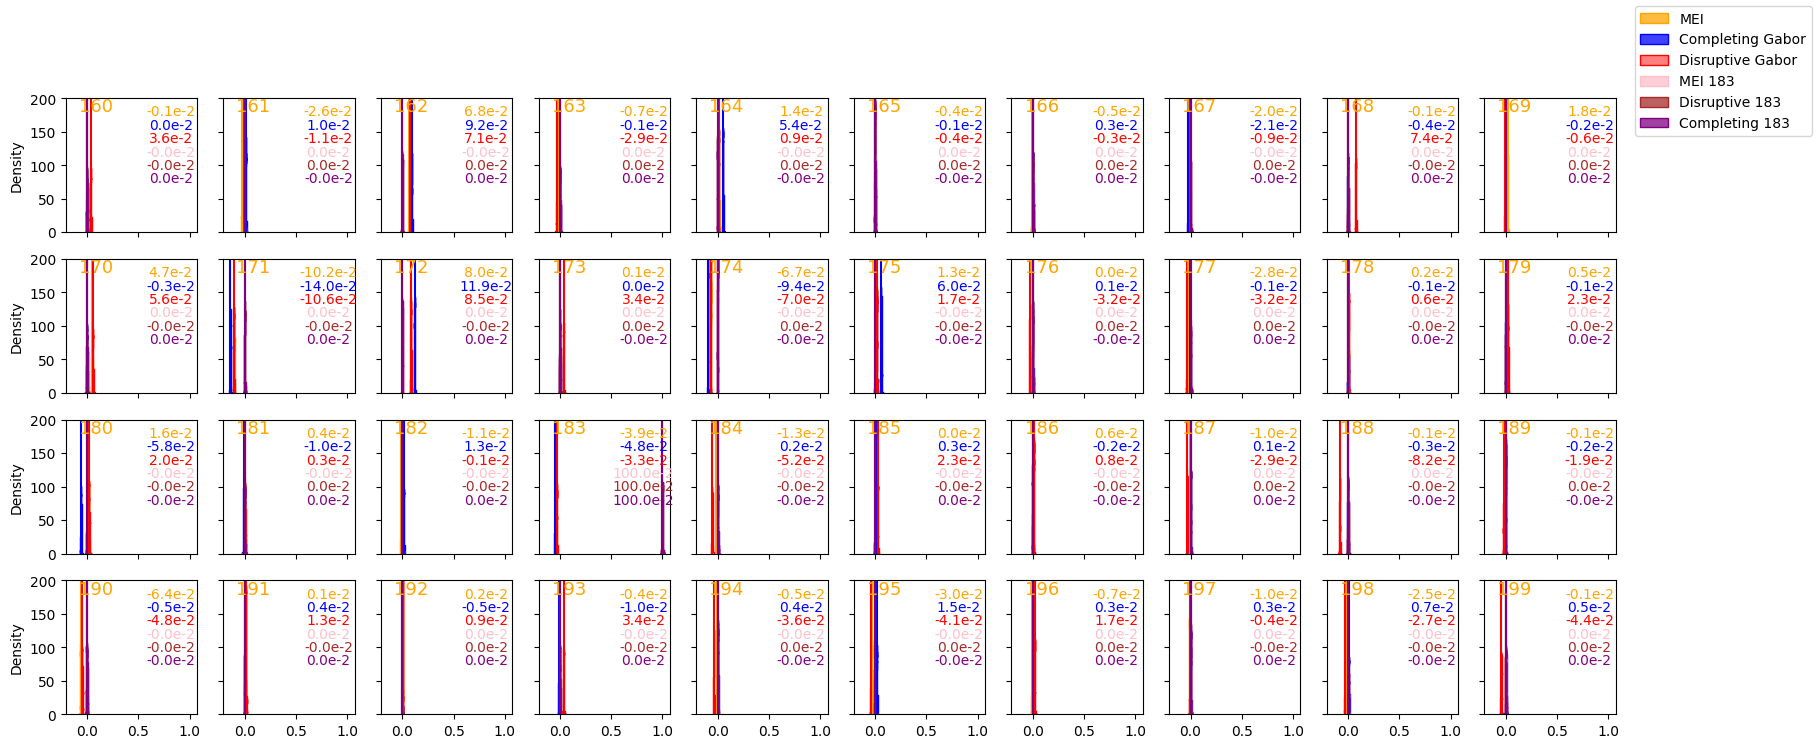

In [95]:
center_offset = 160
fig, axs = plt.subplots(
    nrows=4, ncols=10, figsize=(2 * 10, 2 * 4), sharex=True, sharey=True
)
for i, ax in enumerate(axs.flatten()):
    neuron_id = i + center_offset
    # sns.histplot(
    #     X_prior_samples[:, i],
    #     ax=ax,
    #     stat="density",
    #     label="Prior",
    #     color="green",
    #     element="step",
    # )
    sns.histplot(
        X_samples_mei[:, neuron_id],
        ax=ax,
        stat="density",
        label="MEI",
        color="orange",
        element="step",
    )
    sns.histplot(
        X_samples_ex[:, neuron_id],
        ax=ax,
        stat="density",
        label="Completing Gabor",
        color="blue",
        element="step",
    )
    sns.histplot(
        X_samples_in[:, neuron_id],
        ax=ax,
        stat="density",
        label="Disruptive Gabor",
        color="red",
        element="step",
        alpha=0.5,
    )
    sns.histplot(
        X_samples_mei_183[:, neuron_id],
        ax=ax,
        stat="density",
        label="MEI 183",
        color="pink",
        element="step",
    )
    sns.histplot(
        X_samples_inhibitory_183[:, neuron_id],
        ax=ax,
        stat="density",
        label="Disruptive 183",
        color="brown",
        element="step",
    )
    sns.histplot(
        X_samples_excitatory_183[:, neuron_id],
        ax=ax,
        stat="density",
        label="Completing 183",
        color="purple",
        element="step",
    )
    # ax.axvline(X_prior_samples_mean[neuron_id], color="green", linestyle="-")
    ax.axvline(X_samples_mean_mei[neuron_id], color="orange", linestyle="-")
    ax.axvline(X_samples_mean_ex[neuron_id], color="blue", linestyle="-")
    ax.axvline(X_samples_mean_in[neuron_id], color="red", linestyle="-")
    ax.axvline(X_samples_mean_mei_183[neuron_id], color="pink", linestyle="-")
    ax.axvline(X_samples_mean_inhibitory_183[neuron_id], color="brown", linestyle="-")
    ax.axvline(X_samples_mean_excitatory_183[neuron_id], color="purple", linestyle="-")
    # ax.text(0.8, 0.9, f"{X_prior_samples_mean[neuron_id]*100:.1f}e-2", size=10, ha="center", va="center", transform=ax.transAxes, color='green')
    ax.text(
        0.8,
        0.9,
        f"{X_samples_mean_mei[neuron_id]*100:.1f}e-2",
        size=10,
        ha="center",
        va="center",
        transform=ax.transAxes,
        color="orange",
    )
    ax.text(
        0.8,
        0.8,
        f"{X_samples_mean_ex[neuron_id]*100:.1f}e-2",
        size=10,
        ha="center",
        va="center",
        transform=ax.transAxes,
        color="blue",
    )
    ax.text(
        0.8,
        0.7,
        f"{X_samples_mean_in[neuron_id]*100:.1f}e-2",
        size=10,
        ha="center",
        va="center",
        transform=ax.transAxes,
        color="red",
    )
    ax.text(
        0.8,
        0.6,
        f"{X_samples_mean_mei_183[neuron_id]*100:.1f}e-2",
        size=10,
        ha="center",
        va="center",
        transform=ax.transAxes,
        color="pink",
    )
    ax.text(
        0.8,
        0.5,
        f"{X_samples_mean_inhibitory_183[neuron_id]*100:.1f}e-2",
        size=10,
        ha="center",
        va="center",
        transform=ax.transAxes,
        color="brown",
    )
    ax.text(
        0.8,
        0.4,
        f"{X_samples_mean_excitatory_183[neuron_id]*100:.1f}e-2",
        size=10,
        ha="center",
        va="center",
        transform=ax.transAxes,
        color="purple",
    )
    ax.text(
        0.1,
        0.9,
        str(neuron_id),
        color="orange",
        fontsize=13,
        transform=ax.transAxes,
    )
    # ax.axis("off")
    # ax.set_xlim([-0.5, 0.5])
    # ax.set_xlim([-0.1, 0.1])
    ax.set_ylim([0, 200])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels)

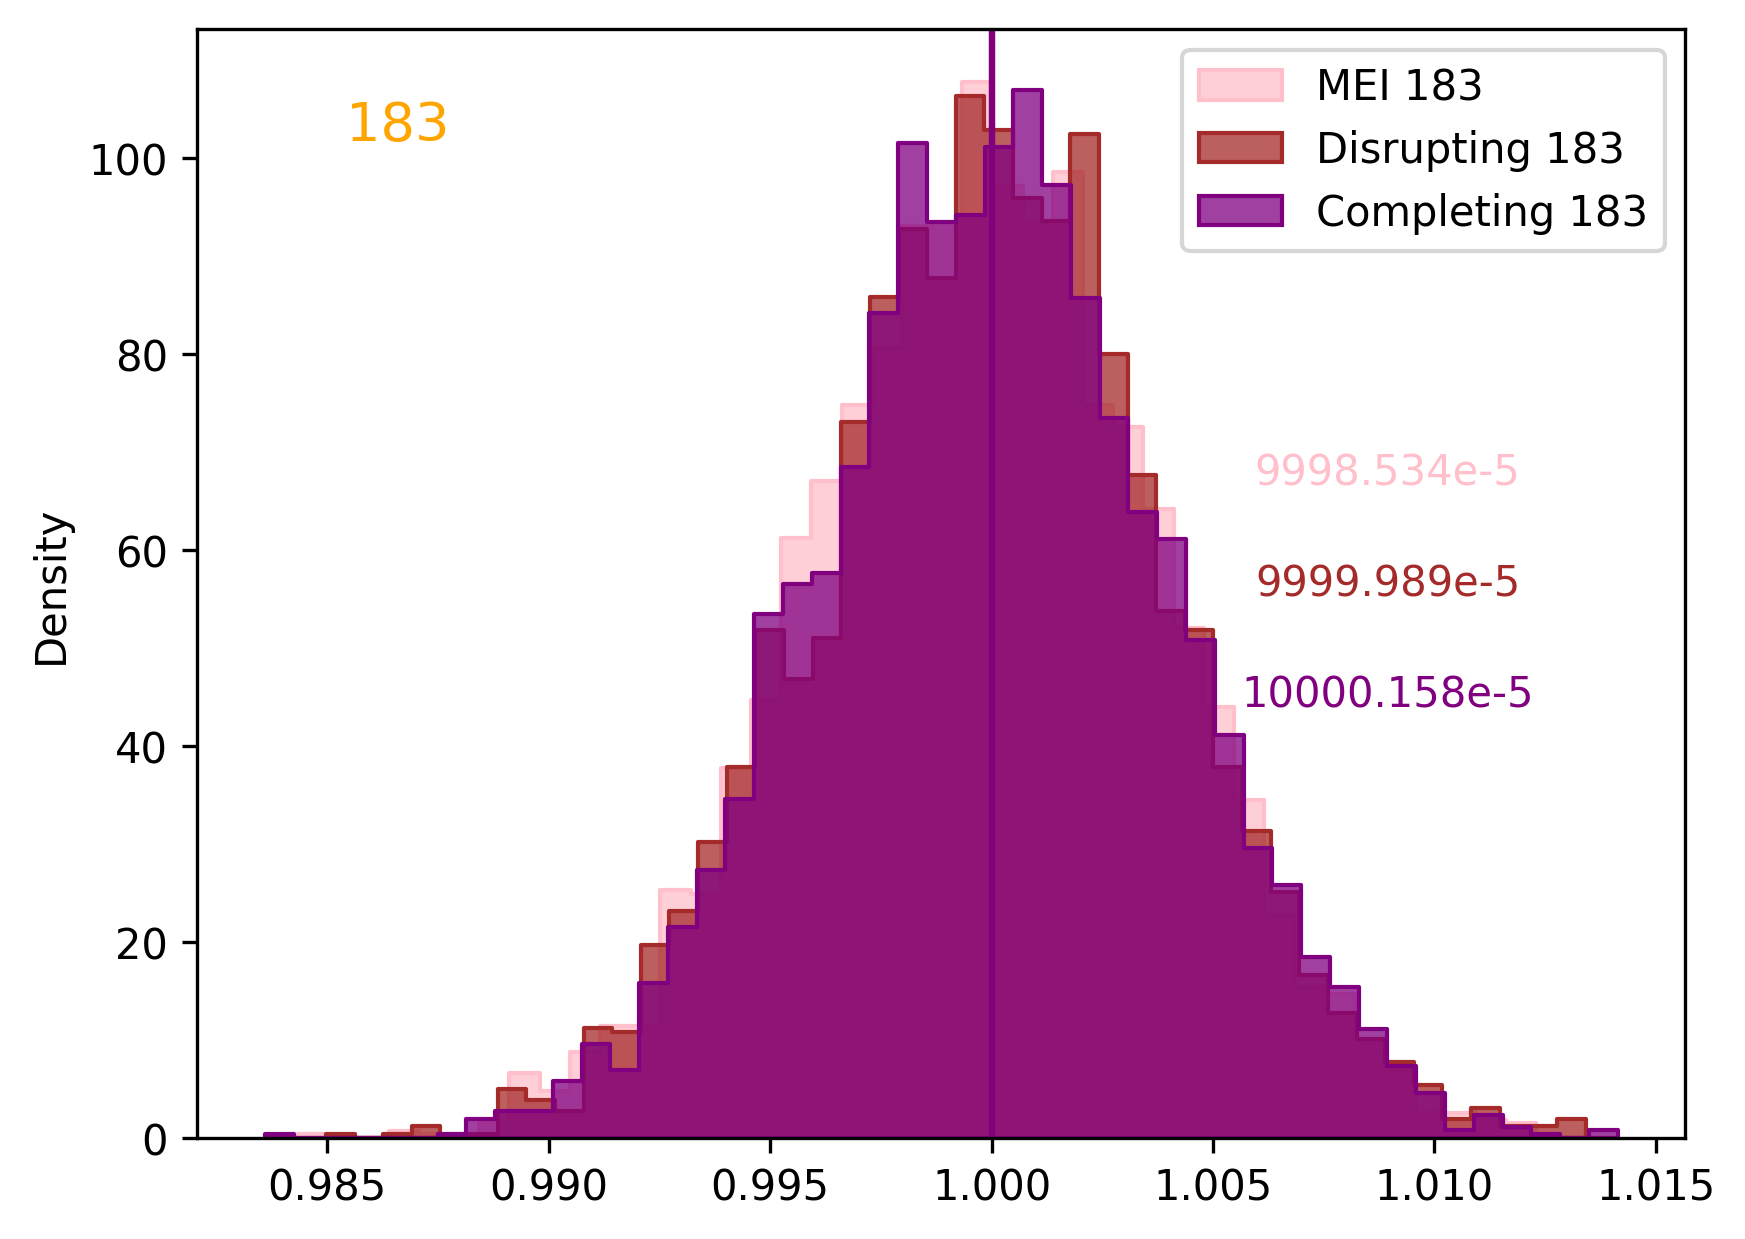

In [93]:
fig, ax = plt.subplots(dpi=300)
neuron_id = 183
sns.histplot(
    X_samples_mei_183[:, neuron_id],
    ax=ax,
    stat="density",
    label="MEI 183",
    color="pink",
    element="step",
)
sns.histplot(
    X_samples_inhibitory_183[:, neuron_id],
    ax=ax,
    stat="density",
    label="Disrupting 183",
    color="brown",
    element="step",
)
sns.histplot(
    X_samples_excitatory_183[:, neuron_id],
    ax=ax,
    stat="density",
    label="Completing 183",
    color="purple",
    element="step",
)
ax.axvline(X_samples_mean_inhibitory_183[neuron_id], color="brown", linestyle="-")
ax.axvline(X_samples_mean_excitatory_183[neuron_id], color="purple", linestyle="-")
ax.text(
    0.8,
    0.6,
    f"{X_samples_mean_mei_183[neuron_id]*10000:.3f}e-5",
    size=10,
    ha="center",
    va="center",
    transform=ax.transAxes,
    color="pink",
)
ax.text(
    0.8,
    0.5,
    f"{X_samples_mean_inhibitory_183[neuron_id]*10000:.3f}e-5",
    size=10,
    ha="center",
    va="center",
    transform=ax.transAxes,
    color="brown",
)
ax.text(
    0.8,
    0.4,
    f"{X_samples_mean_excitatory_183[neuron_id]*10000:.3f}e-5",
    size=10,
    ha="center",
    va="center",
    transform=ax.transAxes,
    color="purple",
)
ax.text(
    0.1,
    0.9,
    str(neuron_id),
    color="orange",
    fontsize=13,
    transform=ax.transAxes,
)
ax.legend()

In [67]:
all_gabors = np.load("all_gabors.npy")
all_gabors.shape

(8, 36, 36)

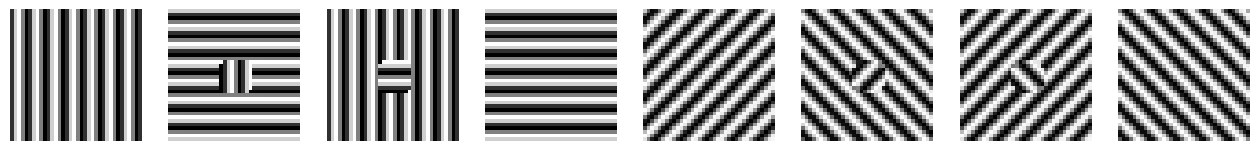

In [71]:
fig, axs = plt.subplots(nrows=1, ncols=8, figsize=(2 * 8, 2 * 1))
for idx, ax in enumerate(axs.flatten()):
    ax.imshow(all_gabors[idx, :, :], cmap="gray")
    ax.axis("off")